In [ ]:
from langgraph.graph import StateGraph,END,START
from typing import TypedDict,Annotated
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode,tools_condition
from llm import llm 
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage,BaseMessage
from langchain_tavily import TavilySearch

In [ ]:
class State(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [ ]:
@tool
def add(a:int , b:int) -> int:
    """Adds two numbers"""
    return a+b
@tool
def multiply(a:int,b:int)->int:
    """Multiply two numbers"""
    return a*b
@tool
def divide(a:int , b:int)->float:
    """Divide two numbers"""
    return a/b
@tool
def web_search(query:str):
    """Tool to fetch latest information from web"""
    search=TavilySearch(max_results=3)
    try:
        results=search.invoke(query)
        return results['results']
    except Exception as e:
        print(e)
        return "Error while fetching the data from the web"


In [ ]:
tools=[add,multiply,divide,web_search]
tlm=llm.bind_tools(tools)
toolnode=ToolNode(tools)

In [ ]:

def brain(state:State):
    res=tlm.invoke(state['messages']) 
    return {'messages':[res]}

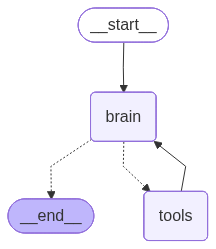

In [ ]:
graph=StateGraph(State)

graph.add_node("brain",brain)
graph.add_node("tools",toolnode)

graph.add_edge(START,"brain")
graph.add_conditional_edges("brain",tools_condition)
graph.add_edge('tools','brain')

wf=graph.compile()
graph.compile()

In [ ]:
res=wf.invoke({"messages":[HumanMessage(content="whats day today ? and 4/9")]})

print(res['messages'][-1].content)

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=web_search {"query": "day today"} </function>\n'}}